1. Generating Network (N=400)...
2. Integrating GLV Dynamics to find true fixed point (this may take a moment)...
3. Extinctions processed. 207/400 species survived.


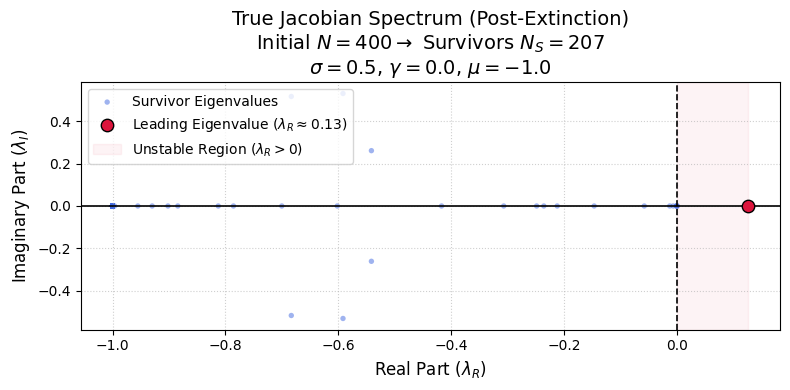

In [49]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def generate_network(N, mean_degree, sigma, gamma, mu):
    raw_sequence = np.random.exponential(mean_degree, N)
    sequence = [int(round(s)) for s in raw_sequence]
    if sum(sequence) % 2 != 0: sequence[0] += 1
        
    G_multi = nx.configuration_model(sequence)
    G = nx.Graph(G_multi)
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_numpy_array(G)
    
    M = np.random.normal(0, sigma, (N, N))
    S = (M + M.T) / np.sqrt(2)
    V = (M - M.T) / np.sqrt(2)
    Alpha = np.sqrt(1 + gamma) * S + np.sqrt(1 - gamma) * V + mu
    
    W = A * Alpha
    return W, G

def plot_true_survivor_spectrum(N, mean_degree, sigma, gamma, mu):
    print(f"1. Generating Network (N={N})...")
    W, G = generate_network(N, mean_degree, sigma, gamma, mu)
    
    print("2. Integrating GLV Dynamics to find true fixed point (this may take a moment)...")
    # Lotka-Volterra ODE: dx/dt = x * (1 - d*x + W*x)
    def glv_deriv(t, x):
        # We use np.maximum to strictly prevent abundances from dropping below absolute zero during integration steps
        x_safe = np.maximum(x, 0)
        return x_safe * (1.0 - x_safe + W @ x_safe)

    # Start all species at a random abundance around 1.0
    x0 = np.random.uniform(0.8, 1.2, N)
    
    # Use BDF (Backward Differentiation Formula) because highly competitive networks become "stiff" equations
    sol = solve_ivp(glv_deriv, [0, 100], x0, method='BDF')
    
    # Extract final abundances
    x_final = sol.y[:, -1]
    
    # 3. Prune extinct species (threshold at 1e-4)
    survivors = x_final > 1e-4
    N_surv = np.sum(survivors)
    print(f"3. Extinctions processed. {N_surv}/{N} species survived.")
    
    if N_surv == 0:
        print("Total ecosystem collapse! No eigenvalues to plot.")
        return

    # 4. Calculate True Jacobian of Survivors
    # J_ij = x_i * W_ij (for i != j)
    # J_ii = x_i * (-d + W_ii)  <-- W_ii is 0 in our setup, so just -d
    W_surv = W[np.ix_(survivors, survivors)]
    x_surv = x_final[survivors]
    
    # True Jacobian matrix evaluated at the survivor fixed point
    J_surv = np.diag(x_surv) @ (W_surv -  np.eye(N_surv))
    
    eigenvalues = np.linalg.eigvals(J_surv)
    max_real_idx = np.argmax(eigenvalues.real)
    leading_eigenvalue = eigenvalues[max_real_idx]
    
    # --- Visualization ---
    plt.figure(figsize=(8, 4), dpi=100) 
    
    plt.scatter(eigenvalues.real, eigenvalues.imag, alpha=0.5, s=15, 
                color='royalblue', edgecolors='none', label='Survivor Eigenvalues')
    
    is_stable = leading_eigenvalue.real <= 1e-5 # Account for floating point 0
    leading_color = 'forestgreen' if is_stable else 'crimson'
    
    plt.scatter(leading_eigenvalue.real, leading_eigenvalue.imag, 
                color=leading_color, s=80, zorder=5, edgecolor='black', linewidth=1,
                label=rf'Leading Eigenvalue ($\lambda_R \approx {leading_eigenvalue.real:.2f}$)')
    
    plt.axhline(0, color='black', linewidth=1.2)
    plt.axvline(0, color='black', linewidth=1.2, linestyle='--')
    
    x_max = max(eigenvalues.real)
    plt.axvspan(0, x_max, color='crimson', alpha=0.05, label=r'Unstable Region ($\lambda_R > 0$)')
    
    plt.xlabel(r'Real Part ($\lambda_R$)', fontsize=12)
    plt.ylabel(r'Imaginary Part ($\lambda_I$)', fontsize=12)
    
    title = (f"True Jacobian Spectrum (Post-Extinction)\n"
             rf"Initial $N={N} \rightarrow$ Survivors $N_S={N_surv}$" "\n"
             rf"$\sigma={sigma}$, $\gamma={gamma}$, $\mu={mu}$")
    plt.title(title, fontsize=14)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# ==========================================
# CONFIGURATION BLOCK
# ==========================================
PARAMS = {
    'N': 400,                   # Lowered to 400 so the ODE solver runs reasonably fast
    'mean_degree': 10,          
    'sigma': 0.5,               
    'gamma': 0.0,               
    'mu': -1.0,                 # A highly competitive regime!
}

plot_true_survivor_spectrum(**PARAMS)